**Import Library & Vizualization Setup**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Vizualization Setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [5]:
file_path = 'Telco_customer_churn.xlsx'
df = pd.read_excel(file_path)

print(f"{df.shape[0]} baris, {df.shape[1]} kolom")
print(df.info())
df.head()

7043 baris, 33 kolom
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Int

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


**Data Cleaning**

In [11]:
# Mengubah spasi kosong string menjadi NaN lalu float pada kolom Total Charges
df['Total Charges'] = df['Total Charges'].replace(" ", np.nan)
df['Total Charges'] = df['Total Charges'].astype(float).fillna(0)

# Hapus kolom ID lokasi dan DATA LEAKAGE (fitur yang baru ada setelah pelanggan churn)
drop_cols = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
    'Lat Long', 'Latitude', 'Longitude', 'Churn Label',
    'Churn Reason', 'Churn Score', 'CLTV'
]

df_clean = df.drop(columns=[col for col in drop_cols if col in df.columns])
df_clean['Churn Value'].value_counts(normalize=True)

,proportion
Churn Value,
0,0.73463
1,0.26537


Distribusi Churn Value menunjukkan imbalanced data sekitar 73% pelanggan bertahan dan 27% churn sehingga evaluasi model nantinya membutuhkan metrik seperti recall dan ROC-AUC, bukan hanya akurasi biasa.

In [12]:
corr = df_clean.apply(lambda x: pd.factorize(x)[0]).corr(method='spearman')
top_corr = corr['Churn Value'].sort_values(ascending=False)
top_corr

,Churn Value
Churn Value,1.000000
Total Charges,0.728664
Contract,0.369247
Tech Support,0.338457
Tenure Months,0.293210
Device Protection,0.280929
Monthly Charges,0.270972
Dependents,0.248542
Streaming Movies,0.198503
Streaming TV,0.196662


Variabel Contract, Tenure Months, dan Total Charges dipilih untuk EDA karena memiliki korelasi terkuat terhadap Churn Value. Contract (0,37) merepresentasikan tingkat komitmen layanan pelanggan, sedangkan Tenure Months (0,29) dan Total Charges (0,73) dipilih untuk menganalisis fase durasi langganan dan aspek finansial yang paling rentan terhadap churn.

**EDA**

/tmp/ipykernel_3631/801882895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='Churn Value', ax=axes[0], palette='Blues_r')


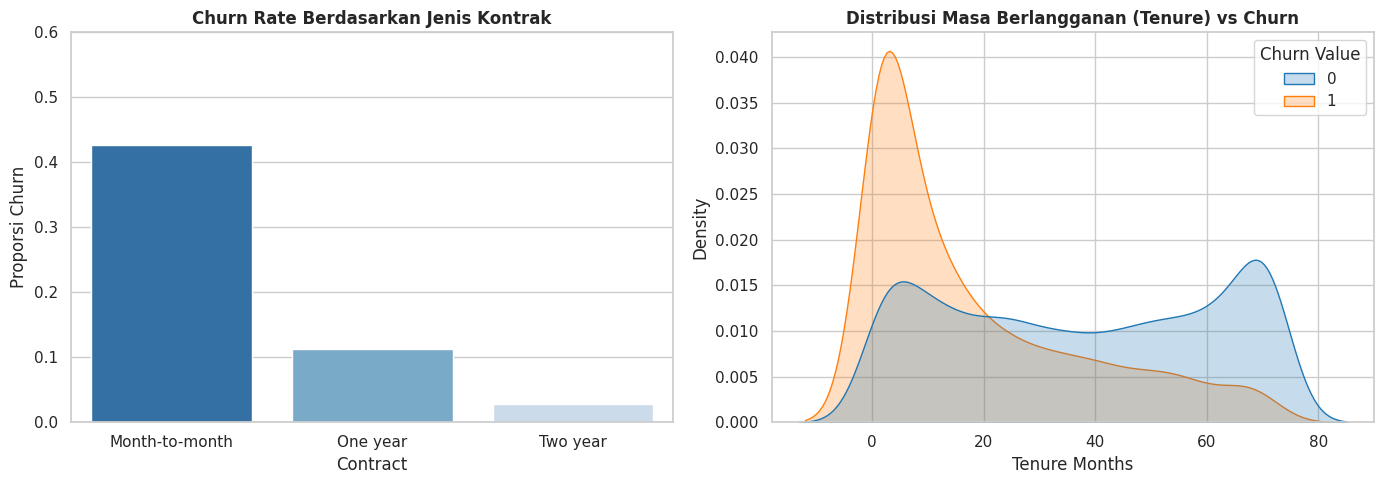

In [13]:
# Visualisasi hubungan Churn dengan Tipe Kontrak & Masa Berlangganan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tingkat Churn berdasarkan Jenis Kontrak
contract_churn = df_clean.groupby('Contract')['Churn Value'].mean().reset_index()
sns.barplot(data=contract_churn, x='Contract', y='Churn Value', ax=axes[0], palette='Blues_r')
axes[0].set_title('Churn Rate Berdasarkan Jenis Kontrak', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Proporsi Churn')
axes[0].set_ylim(0, 0.6)

# Distribusi Tenure Months
sns.kdeplot(data=df_clean, x='Tenure Months', hue='Churn Value', common_norm=False, fill=True, ax=axes[1], palette='tab10')
axes[1].set_title('Distribusi Masa Berlangganan (Tenure) vs Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Pelanggan dengan kontrak Month-to-month memiliki tingkat churn tertinggi (mencapai lebih dari 42%), sedangkan pelanggan dengan komitmen One year dan Two year mengalami penurunan churn yang drastis, masing-masing ke kisaran 11% dan di bawah 3%. Hal ini menunjukkan bahwa ketiadaan ikatan kontrak jangka panjang membuat pelanggan sangat mudah berpindah layanan.

Dilihat dari masa berlangganan (Tenure Months), risiko churn terbesar terpusat pada fase awal, yaitu lonjakan tajam pada rentang 0–10 bulan pertama. Setelah melewati tahun pertama, probabilitas churn menurun drastis dan pelanggan cenderung loyal hingga lebih dari 60 bulan, menegaskan bahwa keberhasilan retensi sangat ditentukan oleh kualitas pendampingan pada masa onboarding.

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df_clean.drop('Churn Value', axis=1)
y = df_clean['Churn Value']

# Stratified Split (80% Train, 20% Test) agar rasio churn sama persis di kedua subset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identifikasi kolom numerik dan kategorikal
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Standardisasi angka dan One-Hot Encoding teks
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

**Baseline Model: Logistic Regression**


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

# Baseline Pipeline dengan penyeimbang bobot kelas
clf_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])

# Training model
clf_lr.fit(X_train, y_train)
# Melakukan prediksi pada data uji
y_pred_lr = clf_lr.predict(X_test)
y_proba_lr = clf_lr.predict_proba(X_test)[:, 1]

print("EVALUASI (LOGISTIC REGRESSION)")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba_lr), 4))

EVALUASI (LOGISTIC REGRESSION)
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409

ROC-AUC Score: 0.8489


Model Logistic Regression ini bekerja sangat baik untuk mendeteksi pelanggan yang mau kabur. Dari 374 pelanggan yang aslinya churn, model berhasil menangkap 78% di antaranya. Skor ROC-AUC yang tinggi di angka 0,85 juga membuktikan model ini pintar membedakan mana pelanggan setia dan mana yang berisiko pergi, bukan sekadar tebak-tebakan acak.

Memang ada kompromi di nilai precision sebesar 51%, yang artinya masih ada pelanggan setia yang ikut tertebak mau kabur. Namun, secara bisnis ini tetap menguntungkan. Mengeluarkan sedikit biaya untuk memberi promo retensi ke orang yang salah jauh lebih murah daripada kehilangan pelanggan dan harus keluar modal besar untuk mencari pelanggan baru. Akurasi akhir di angka 74% menunjukkan model ini objektif dan tidak malas karena berhasil mengenali pelanggan churn dengan baik.

**Random Forest Classifier**

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Pipeline Random Forest
clf_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42))
])

clf_rf.fit(X_train, y_train)
y_pred_rf = clf_rf.predict(X_test)
y_proba_rf = clf_rf.predict_proba(X_test)[:, 1]

print("EVALUASI(RANDOM FOREST)")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_proba_rf), 4))

EVALUASI(RANDOM FOREST)
              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409

ROC-AUC Score: 0.8515


Secara keseluruhan, Random Forest unggul tipis hampir di semua metrik. Akurasinya naik menjadi 76% dan skor ROC-AUC meningkat ke 0,8515. Nilai presisinya juga membaik menjadi 53%, yang artinya tebakan model saat mencurigai pelanggan akan churn menjadi sedikit lebih akurat dibanding Logistic Regression.

Meskipun nilai recall pada Random Forest turun sangat tipis (dari 78% ke 77%), selisih 1% ini terkompensasi dengan berkurangnya false positive (salah target promosi). Oleh karena itu, Random Forest lebih direkomendasikan sebagai model final karena menghasilkan performa prediksi yang lebih seimbang dan stabil.

**Faktor Penentu Churn**

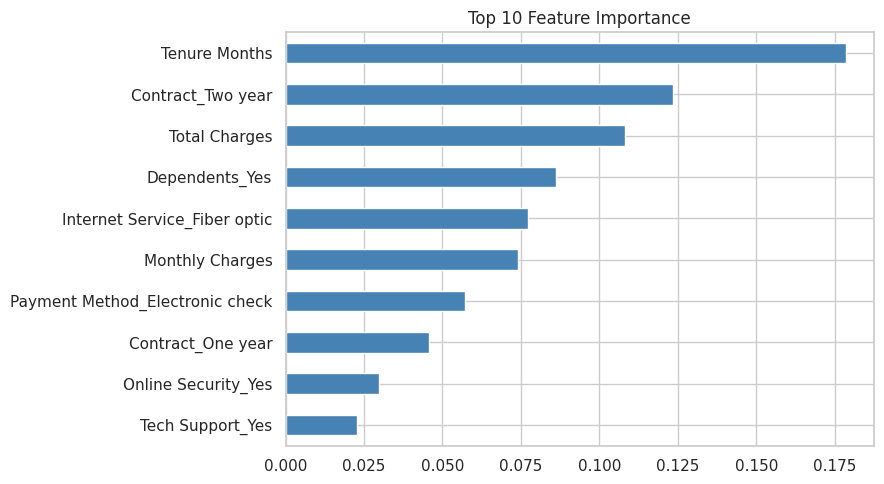

In [26]:
# Ambil fitur yang telah di-encode
encoder = clf_rf.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = encoder.get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_feature_names)

# Ambil nilai feature importance dari Random Forest
importances = clf_rf.named_steps['classifier'].feature_importances_
feat_importances = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
feat_importances.plot(kind='barh', color='steelblue').invert_yaxis()
plt.title('Top 10 Feature Importance')
plt.tight_layout()
plt.show()

Hasil feature importance dari model Random Forest menunjukkan bahwa Tenure Months (masa berlangganan) merupakan faktor paling dominan dengan bobot tertinggi dalam memprediksi churn, disusul oleh komitmen kontrak jangka panjang seperti Contract_Two year dan Contract_One year. Hal ini mengonfirmasi bahwa pelanggan yang baru bergabung jauh lebih rentan untuk berhenti dibandingkan mereka yang sudah lama berlangganan atau terikat kontrak tahunan. Selain durasi dan komitmen, beban finansial yang tercermin dari variabel Total Charges dan Monthly Charges juga menempati urutan teratas, menandakan besarnya biaya tagihan bulanan menjadi pemicu penting bagi pelanggan untuk mempertimbangkan pindah layanan.

Risiko churn terbesar terpusat pada pelanggan baru berkontrak bulanan dengan beban biaya yang dirasa memberatkan. Oleh karena itu, bisnis sebaiknya difokuskan pada penguatan pendampingan pelanggan baru di beberapa bulan awal serta pemberian penawaran insentif agar pelanggan mau beralih ke skema kontrak minimal satu tahun.